In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import gradio as gr
sns.set_style("whitegrid")

In [3]:
df = pd.read_csv("student_pass_fail.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   study_hours            300 non-null    float64
 1   attendance_percentage  300 non-null    float64
 2   previous_exam_score    300 non-null    float64
 3   sleep_hours            300 non-null    float64
 4   passed                 300 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.8 KB


In [5]:
df.head()

,study_hours,attendance_percentage,previous_exam_score,sleep_hours,passed
0,3.7,43.1,41.8,5.0,0
1,9.5,71.9,49.5,4.1,1
2,7.3,72.4,42.4,4.9,0
3,6.0,78.2,36.2,6.9,1
4,1.6,83.6,38.4,6.1,0


In [6]:
df.describe()

,study_hours,attendance_percentage,previous_exam_score,sleep_hours,passed
count,300.000000,300.000000,300.000000,300.000000,300.000000
mean,4.954667,70.651333,62.976667,6.597333,0.500000
std,2.942710,18.155835,19.843771,1.484837,0.500835
min,0.100000,40.700000,30.300000,4.000000,0.000000
25%,2.400000,54.975000,44.700000,5.300000,0.000000
50%,5.100000,71.300000,61.700000,6.750000,0.500000
75%,7.600000,86.375000,80.175000,7.925000,1.000000
max,9.900000,100.000000,99.800000,9.000000,1.000000


In [7]:
df["passed"].value_counts()

,count
passed,
0,150
1,150


<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

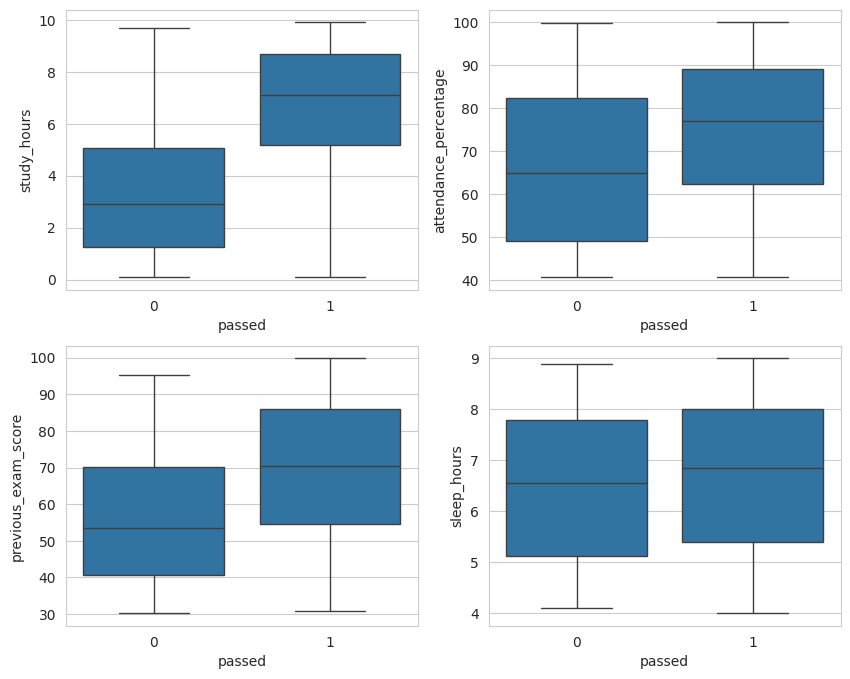

In [8]:
fig,axes = plt.subplots(2,2,figsize=(10,8))
for ax, feature in zip(axes.flatten(),df.columns[:-1]):
    sns.boxplot(data=df,x="passed",y=feature,ax=ax)
plt.tight_layout

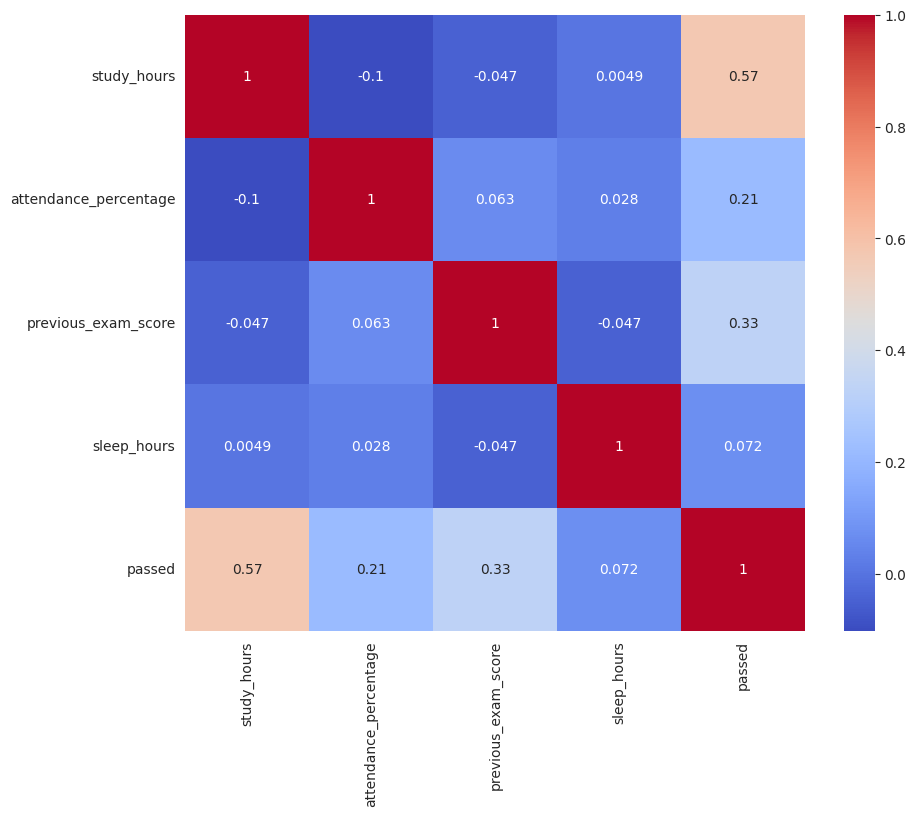

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.show()

# Split

In [11]:
X = df.drop("passed",axis=1)
y = df["passed"]

In [12]:
X.head()

,study_hours,attendance_percentage,previous_exam_score,sleep_hours
0,3.7,43.1,41.8,5.0
1,9.5,71.9,49.5,4.1
2,7.3,72.4,42.4,4.9
3,6.0,78.2,36.2,6.9
4,1.6,83.6,38.4,6.1


In [14]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [15]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
model = DecisionTreeClassifier(max_depth=4,random_state=42)
model.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

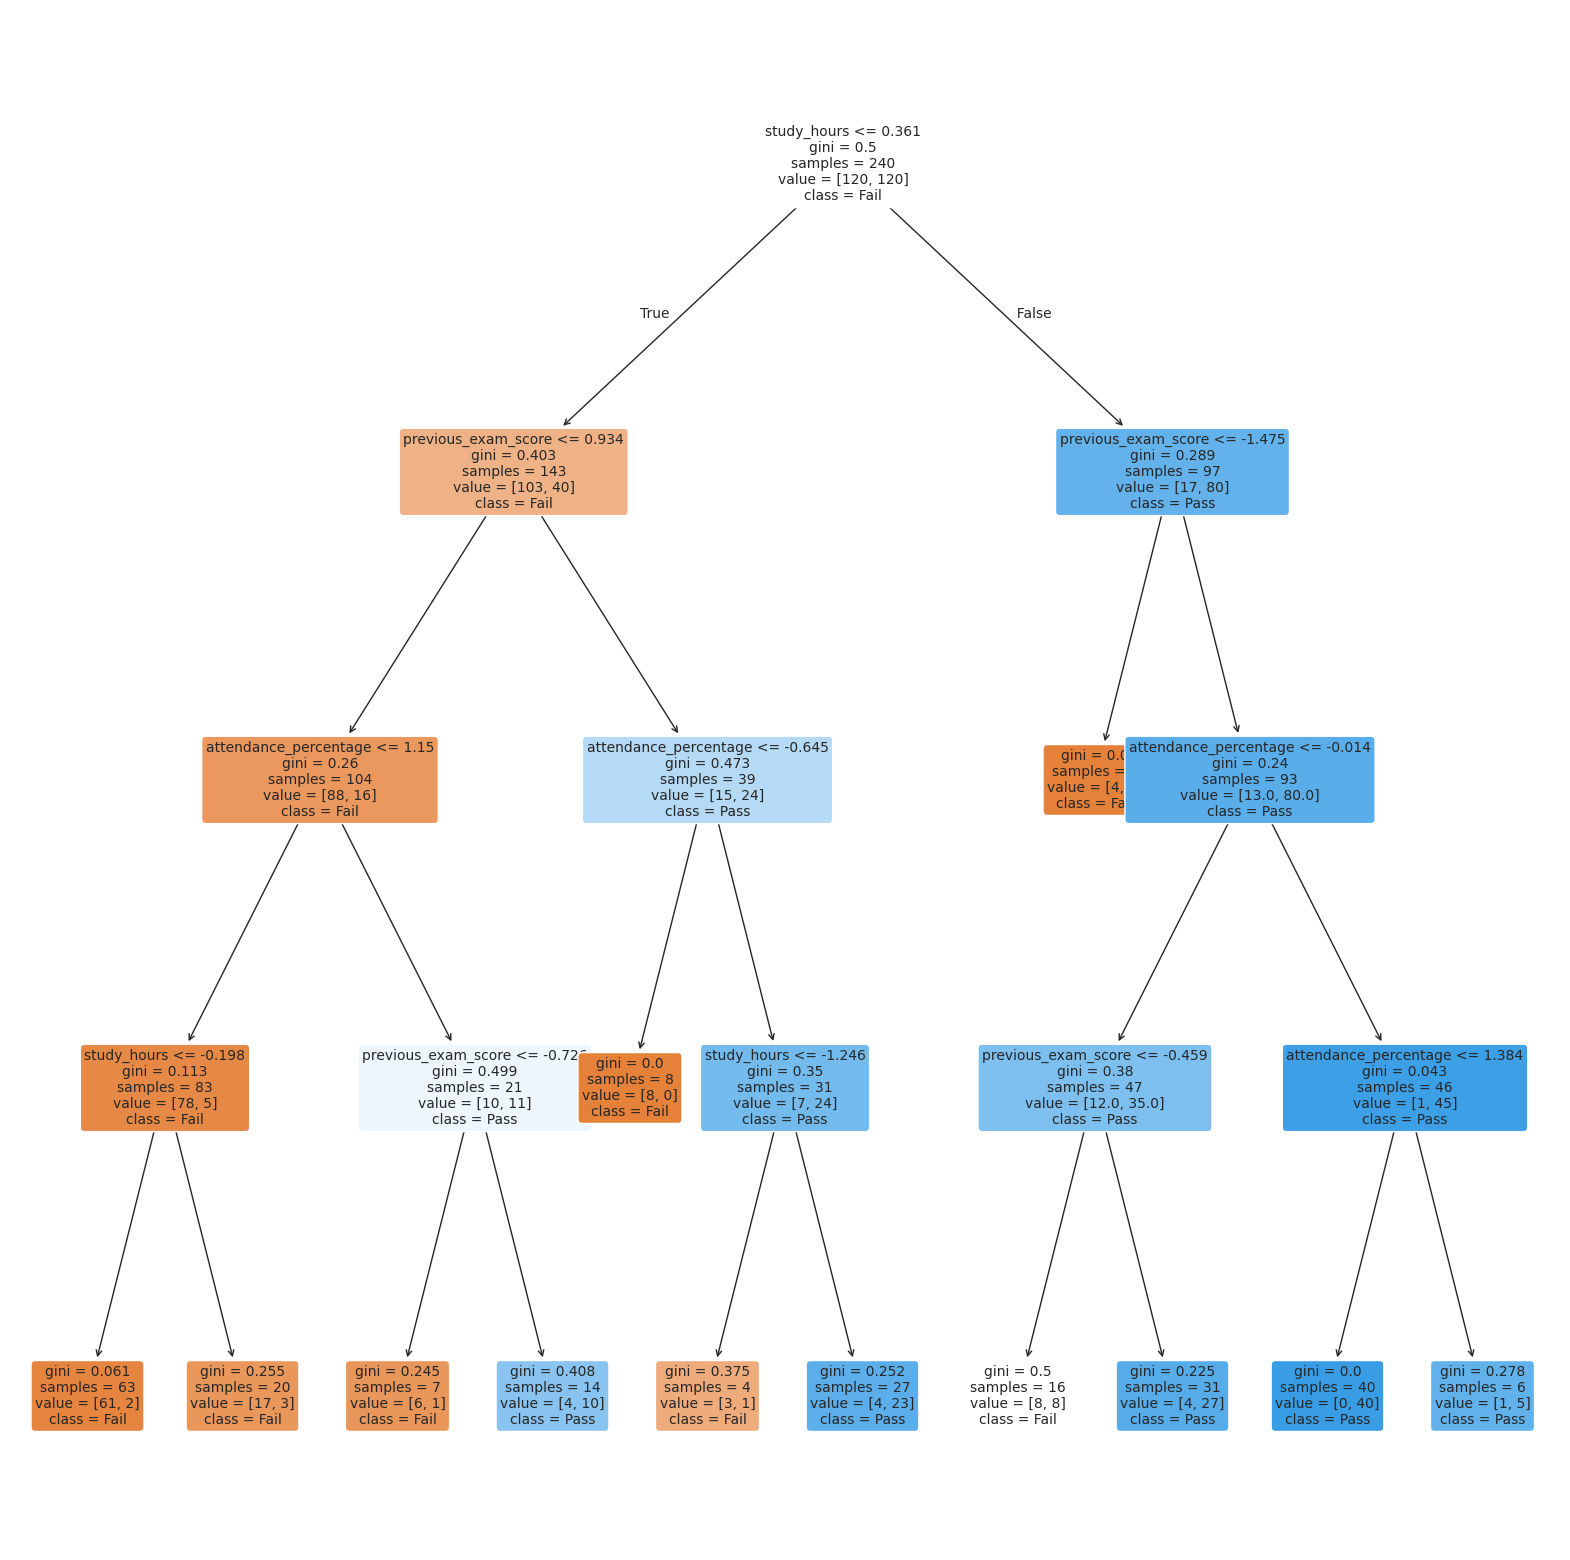

In [19]:
plt.figure(figsize=(20,20))
plot_tree(model,feature_names=X.columns,class_names=["Fail","Pass"],filled=True,rounded=True,fontsize=10)
plt.show()

# Evaluation

In [20]:
y_pred = model.predict(X_test)

In [21]:
accuaracy = accuracy_score(y_test,y_pred)
print(f"Accuracy: {accuaracy}")

Accuracy: 0.8166666666666667


<Axes: >

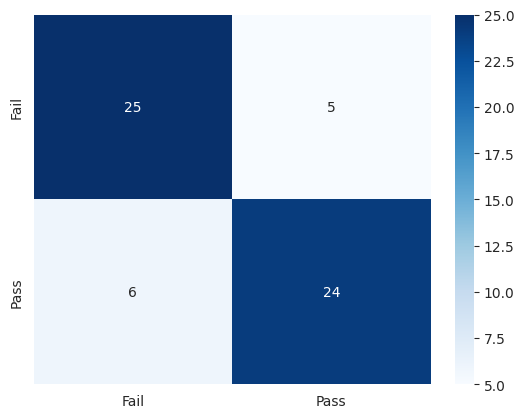

In [22]:
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["Fail","Pass"],yticklabels=["Fail","Pass"])

In [ ]:
import gradio as gr

def predict_pass_fail(study_hours, attendance_percentage, previous_exam_score, sleep_hours):
    input_df = pd.DataFrame([{
        "study_hours": study_hours,
        "attendance_percentage": attendance_percentage,
        "previous_exam_score": previous_exam_score,
        "sleep_hours": sleep_hours
    }])

    input_scaled = scaler.transform(input_df)

    prediction = model.predict(input_scaled)[0]
    probability = model.predict_proba(input_scaled)[0]

    label = "Pass" if prediction == 1 else " Fail"
    confidence = probability[prediction]

    return f"{label}  (confidence: {confidence:.1%})"


demo = gr.Interface(
    fn=predict_pass_fail,
    inputs=[
        gr.Slider(0, 10, value=5, step=0.5, label="Study Hours (per day)"),
        gr.Slider(40, 100, value=75, step=1, label="Attendance Percentage"),
        gr.Slider(30, 100, value=60, step=1, label="Previous Exam Score"),
        gr.Slider(4, 9, value=7, step=0.5, label="Sleep Hours"),
    ],
    outputs=gr.Textbox(label="Prediction"),
    title="🎓 Student Pass/Fail Predictor (Decision Tree)",
    description="Move the sliders to see how the Decision Tree predicts pass/fail."
)

demo.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8e9937cb54b2dfa8c7.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
